✓ Ready
PROJECT_DIR: C:\python\Intelligent_Sketch2CAD
IMAGE_PATH: C:\python\Intelligent_Sketch2CAD\input_data\raw_sketches\WhatsApp Image 2026-04-24 at 21.41.48.jpeg
Image loaded: (2048, 1152, 3)


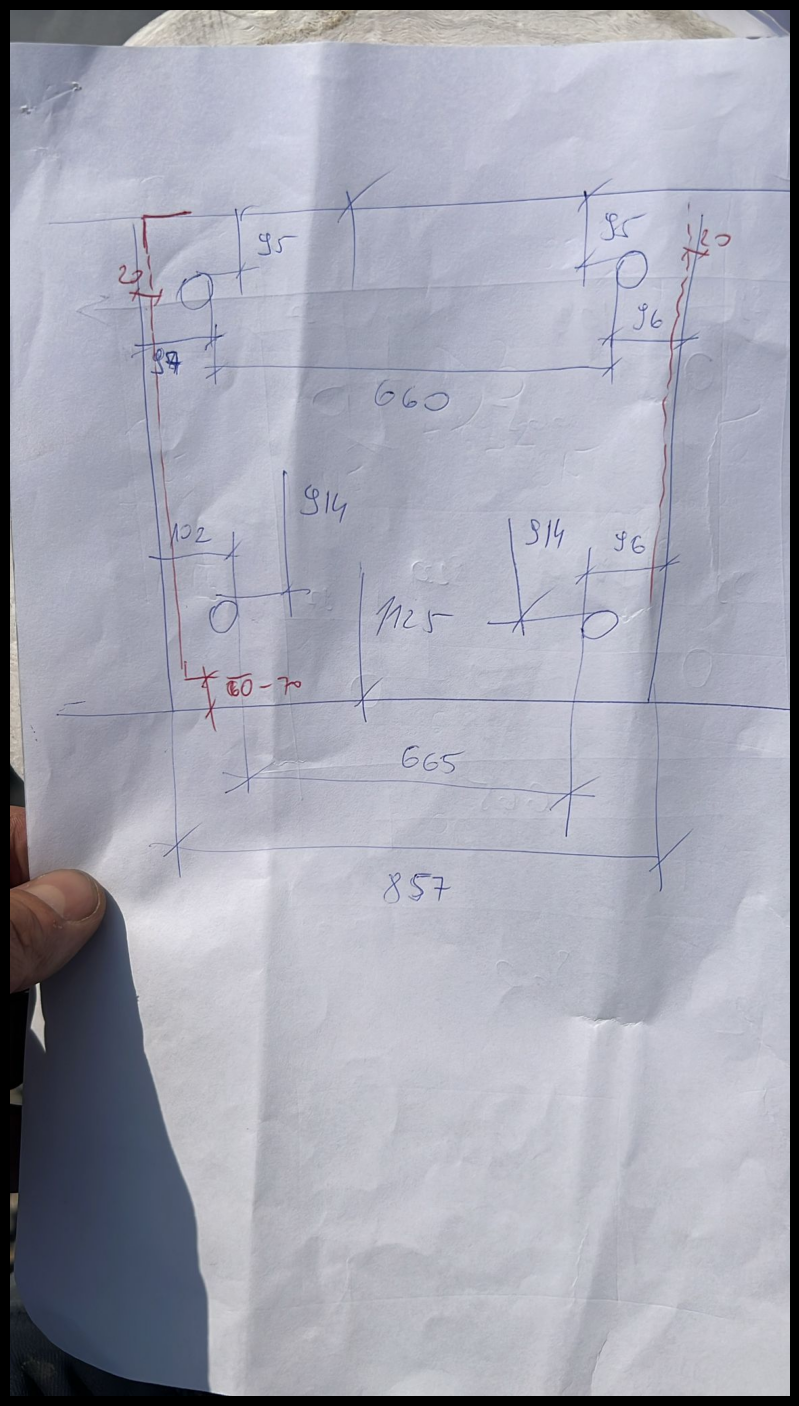

In [1]:
# Vertical Slice - Sketch2CAD Pipeline (English)
# Process: RAW Image → SAM2 Masking → Adaptive Threshold → DeepLSD → Classification → DXF/PDF

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from datetime import datetime
import os
import glob
import json
import sys
import ipywidgets as widgets
from IPython.display import display

print("✓ Ready")

# -------------------------------
# ABSOLUTE PATHS
PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
INPUT_DIR = PROJECT_DIR / "input_data"
RAW_SKETCHES_DIR = INPUT_DIR / "raw_sketches"
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
OUTPUT_DIR = PROJECT_DIR / "output_data"

# Input file
IMAGE_PATH = RAW_SKETCHES_DIR / "WhatsApp Image 2026-04-24 at 21.41.48.jpeg"

# Create output folders
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("IMAGE_PATH:", IMAGE_PATH)

# -------------------------------
# LOAD IMAGE
img_bgr = cv2.imread(str(IMAGE_PATH))
if img_bgr is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Image loaded:", img_rgb.shape)
plt.figure(figsize=(12, 18))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [2]:

# -------------------------------
# SAM2 MASKING – EXTRACT DRAWING
checkpoint_path = "sam2_hiera_small.pt"
config_path = "sam2_hiera_s.yaml"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

sam2_model = build_sam2(config_path, checkpoint_path, device=device)
predictor = SAM2ImagePredictor(sam2_model)

image_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
predictor.set_image(image_rgb)

mask_generator = SAM2AutomaticMaskGenerator(sam2_model)
masks = mask_generator.generate(image_rgb)
print(f"Generated {len(masks)} masks")

# Largest mask (the paper)
masks_sorted = sorted(masks, key=lambda x: x['area'], reverse=True)
paper_mask = masks_sorted[0]
mask = paper_mask['segmentation']

# White background with only the drawing
white_background = np.ones_like(image_rgb) * 255
white_background[mask] = image_rgb[mask]

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
result_bgr = cv2.cvtColor(white_background, cv2.COLOR_RGB2BGR)
result_path = INTERMEDIATE_DIR / f"drawing_on_white_{timestamp}.jpg"
cv2.imwrite(str(result_path), result_bgr)
print(f"✓ Saved: {result_path}")

# Crop tightly around drawing
y_indices, x_indices = np.where(mask)
if len(y_indices) > 0:
    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    padding = 20
    x_min = max(0, x_min - padding)
    x_max = min(white_background.shape[1], x_max + padding)
    y_min = max(0, y_min - padding)
    y_max = min(white_background.shape[0], y_max + padding)
    cropped_tight = white_background[y_min:y_max, x_min:x_max]
    tight_path = INTERMEDIATE_DIR / f"drawing_tight_{timestamp}.jpg"
    cv2.imwrite(str(tight_path), cv2.cvtColor(cropped_tight, cv2.COLOR_RGB2BGR))
    print(f"✓ Tight crop: {tight_path}")
else:
    cropped_tight = white_background

Using device: cpu
Generated 8 masks
✓ Saved: C:\python\Intelligent_Sketch2CAD\intermediate_data\drawing_on_white_20260511_190216.jpg
✓ Tight crop: C:\python\Intelligent_Sketch2CAD\intermediate_data\drawing_tight_20260511_190216.jpg


In [3]:
# -------------------------------
# THRESHOLD WIDGET (interactive)
test_image = cropped_tight.copy()
gray_test = cv2.cvtColor(test_image, cv2.COLOR_RGB2GRAY)
out = widgets.Output()


def apply_global_threshold(threshold):
    _, binary = cv2.threshold(gray_test, threshold, 255, cv2.THRESH_BINARY)
    return binary


def apply_adaptive_threshold(block_size, C):
    if block_size % 2 == 0: block_size += 1
    if block_size < 3: block_size = 3
    return cv2.adaptiveThreshold(gray_test, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, block_size, C)


def update_visualization(threshold=127, use_adaptive=False, block_size=15, C=5):
    with out:
        out.clear_output(wait=True)
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes[0, 0].imshow(gray_test, cmap='gray');
        axes[0, 0].set_title("1. Original Grayscale");
        axes[0, 0].axis('off')
        axes[0, 1].hist(gray_test.ravel(), bins=256, range=(0, 255), color='black')
        axes[0, 1].axvline(x=threshold, color='red', linestyle='--', label=f'Threshold={threshold}')
        axes[0, 1].set_title("2. Histogram");
        axes[0, 1].legend()
        if use_adaptive:
            binary = apply_adaptive_threshold(block_size, C)
            axes[0, 2].set_title(f"3. Adaptive (block={block_size}, C={C})")
        else:
            binary = apply_global_threshold(threshold)
            axes[0, 2].set_title(f"3. Global Threshold (T={threshold})")
        axes[0, 2].imshow(binary, cmap='gray');
        axes[0, 2].axis('off')
        h, w = binary.shape
        ch, cw = h // 2, w // 2
        zoom_size = min(500, h, w)
        zoom = binary[ch - zoom_size // 2:ch + zoom_size // 2, cw - zoom_size // 2:cw + zoom_size // 2]
        axes[1, 0].imshow(zoom, cmap='gray');
        axes[1, 0].set_title("4. Detail Zoom");
        axes[1, 0].axis('off')
        axes[1, 1].axis('off');
        axes[1, 2].axis('off')
        plt.tight_layout();
        plt.show()
        print(
            f"Binary: {binary.shape[1]}x{binary.shape[0]}, white={np.sum(binary == 255)}, black={np.sum(binary == 0)}")


threshold_slider = widgets.IntSlider(value=127, min=0, max=255, step=1, description='Threshold:')
use_adaptive_cb = widgets.Checkbox(value=False, description='Use Adaptive Threshold')
block_size_slider = widgets.IntSlider(value=15, min=3, max=51, step=2, description='Block size:')
C_slider = widgets.IntSlider(value=5, min=0, max=20, step=1, description='C:')

print("=" * 60);
print("THRESHOLD WIDGET - find optimal threshold");
print("=" * 60)
widgets.interactive(update_visualization,
                    threshold=threshold_slider,
                    use_adaptive=use_adaptive_cb,
                    block_size=block_size_slider,
                    C=C_slider)
display(threshold_slider, use_adaptive_cb, block_size_slider, C_slider, out)
update_visualization(127, False, 15, 5)

THRESHOLD WIDGET - find optimal threshold


IntSlider(value=127, description='Threshold:', max=255)

Checkbox(value=False, description='Use Adaptive Threshold')

IntSlider(value=15, description='Block size:', max=51, min=3, step=2)

IntSlider(value=5, description='C:', max=20)

Output()

Adaptive threshold: block=25, C=20


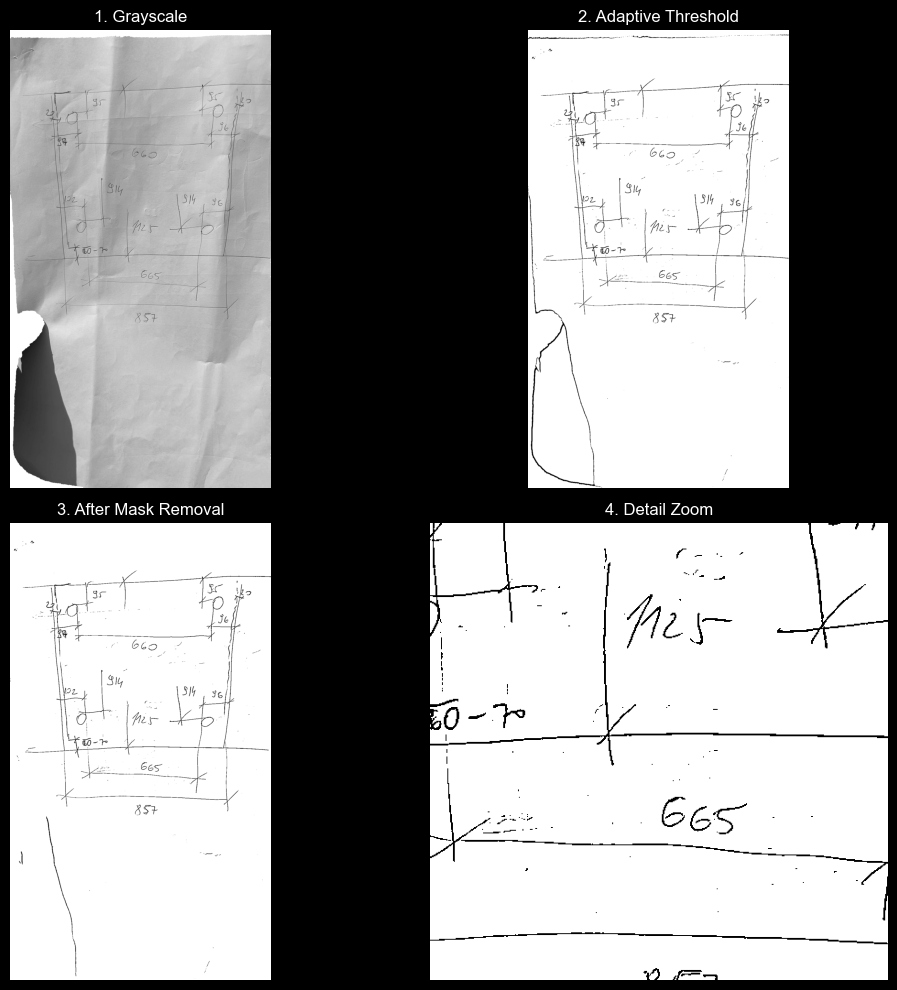


✓ Saved: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260511_190216.jpg


In [4]:

# -------------------------------
# ADAPTIVE THRESHOLD + MASK REMOVAL
# Use cropped_tight from memory
if 'cropped_tight' in locals():
    test_image = cropped_tight
else:
    pattern = str(INTERMEDIATE_DIR / "drawing_tight_*.jpg")
    files = glob.glob(pattern)
    latest = max(files, key=os.path.getctime)
    test_image = cv2.imread(latest)
    test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(test_image, cv2.COLOR_RGB2GRAY)

window_size = 25
C = 20
binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY, window_size, C)
print(f"Adaptive threshold: block={window_size}, C={C}")

# Crop mask to same size
y_indices, x_indices = np.where(mask)
x_min, x_max = np.min(x_indices), np.max(x_indices)
y_min, y_max = np.min(y_indices), np.max(y_indices)
padding = 20
x_min = max(0, x_min - padding)
x_max = min(mask.shape[1], x_max + padding)
y_min = max(0, y_min - padding)
y_max = min(mask.shape[0], y_max + padding)
mask_cropped = mask[y_min:y_max, x_min:x_max]

# Shrink mask to remove border artifacts
mask_uint8 = (mask_cropped * 255).astype(np.uint8)
shrink = 15
kernel_shrink = np.ones((shrink, shrink), np.uint8)
mask_shrinked = cv2.erode(mask_uint8, kernel_shrink, iterations=1) > 0

final = binary.copy()
final[~mask_shrinked] = 255

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1);
plt.imshow(gray, cmap='gray');
plt.title("1. Grayscale");
plt.axis('off')
plt.subplot(2, 2, 2);
plt.imshow(binary, cmap='gray');
plt.title("2. Adaptive Threshold");
plt.axis('off')
plt.subplot(2, 2, 3);
plt.imshow(final, cmap='gray');
plt.title("3. After Mask Removal");
plt.axis('off')
if final.shape[0] > 500 and final.shape[1] > 500:
    ch, cw = final.shape[0] // 2, final.shape[1] // 2
    zoom = final[ch - 250:ch + 250, cw - 250:cw + 250]
    plt.subplot(2, 2, 4);
    plt.imshow(zoom, cmap='gray');
    plt.title("4. Detail Zoom");
    plt.axis('off')
plt.tight_layout();
plt.show()

binary_path = INTERMEDIATE_DIR / f"adaptive_cleaned_{timestamp}.jpg"
cv2.imwrite(str(binary_path), final)
print(f"\n✓ Saved: {binary_path}")

Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260511_190216.jpg


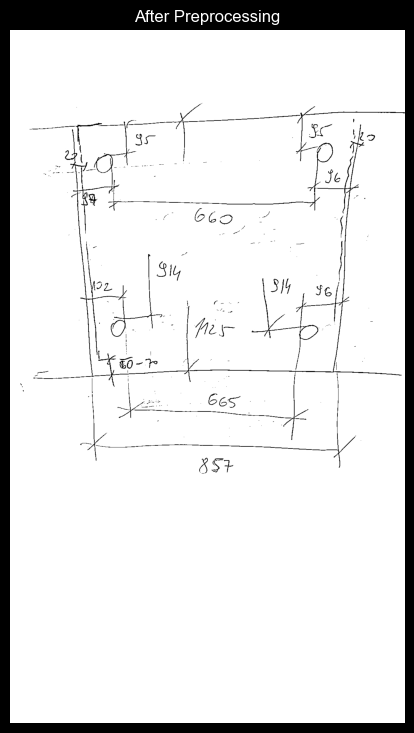

In [5]:

# -------------------------------
# SKETCH → CAD: DeepLSD v6
PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
DEEPLSD_DIR = PROJECT_DIR / "DeepLSD"
WEIGHTS_PATH = DEEPLSD_DIR / "weights" / "deeplsd_md.tar"

pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)
latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
if np.mean(gray) < 128:
    gray = cv2.bitwise_not(gray)
    print("Polarity fixed (white bg, black lines)")

# --- Preprocessing: component filtering ---
contour_img = cv2.bitwise_not(gray)
contours, _ = cv2.findContours(contour_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    main_contour = max(contours, key=cv2.contourArea)
    mask_inside = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_inside, [main_contour], -1, 255, thickness=cv2.FILLED)
    mask_edge = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_edge, [main_contour], -1, 255, thickness=2)
    mask_near = cv2.dilate(mask_edge, np.ones((120, 120), np.uint8), iterations=1)
    cc_img = cv2.bitwise_not(gray)
    _, labels, stats, _ = cv2.connectedComponentsWithStats(cc_img, connectivity=8)
    mask_final = np.zeros_like(gray, dtype=np.uint8)
    for label in range(1, len(stats)):
        comp_mask = (labels == label).astype(np.uint8) * 255
        area = stats[label, cv2.CC_STAT_AREA]
        if cv2.bitwise_and(comp_mask, mask_inside).any():
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
        elif cv2.bitwise_and(comp_mask, mask_near).any() and area < 1500:
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
    gray_filtered = cv2.bitwise_and(gray, mask_final)
    gray_filtered[mask_final == 0] = 255
    gray = gray_filtered

plt.figure(figsize=(6, 9))
plt.imshow(gray, cmap='gray');
plt.title("After Preprocessing");
plt.axis('off');
plt.show()

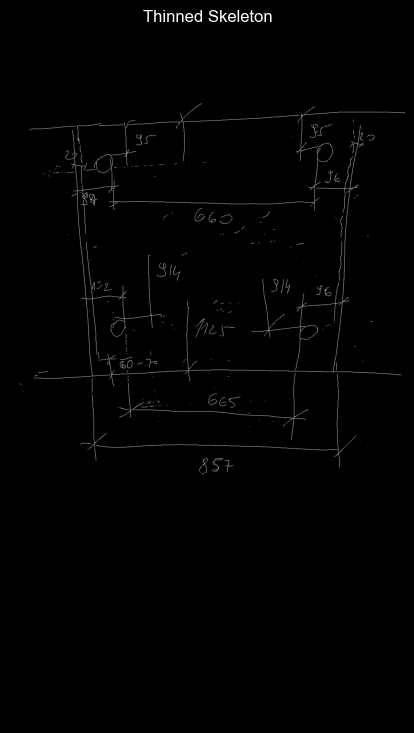

✓ Thinning done


In [6]:

# --- Thinning ---
binary_thin = cv2.bitwise_not(gray)
skeleton = cv2.ximgproc.thinning(binary_thin, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
h, w = skeleton.shape
plt.figure(figsize=(6, 9))
plt.imshow(skeleton, cmap='gray');
plt.title("Thinned Skeleton");
plt.axis('off');
plt.show()
print("✓ Thinning done")

✓ Model loaded
DeepLSD detected: 344 raw segments


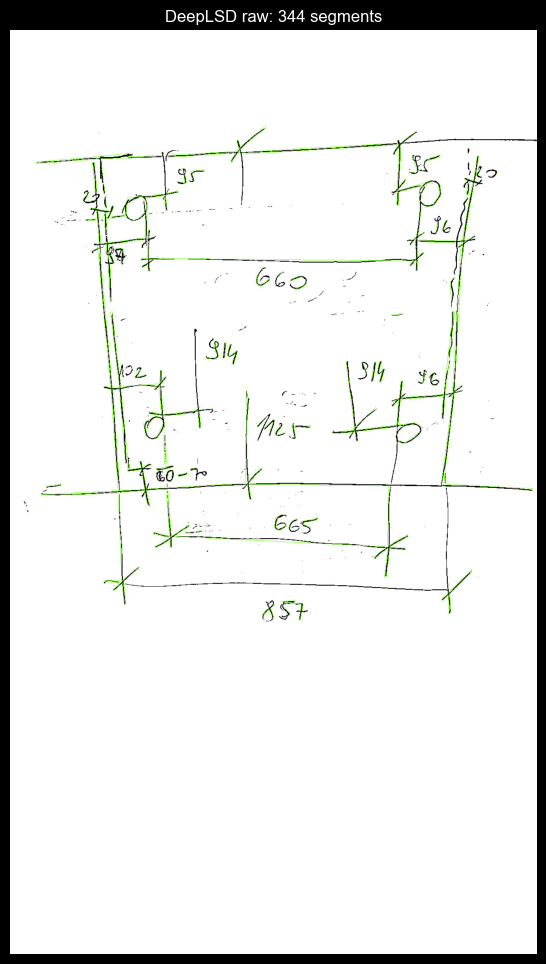

In [7]:

# --- DeepLSD ---
sys.path.insert(0, str(DEEPLSD_DIR))
from deeplsd.models.deeplsd_inference import DeepLSD

device = torch.device('cpu')
conf = {
    'detect_lines': True,
    'line_detection_params': {
        'merge': True, 'filtering': True,
        'grad_thresh': 2, 'grad_nfa': True,
    }
}
ckpt = torch.load(str(WEIGHTS_PATH), map_location=device, weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net.eval()
print("✓ Model loaded")

img_tensor = torch.tensor(gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
with torch.no_grad():
    out = net({'image': img_tensor})
lines_raw = out['lines'][0]
print(f"DeepLSD detected: {len(lines_raw)} raw segments")

all_segments = []
for line in lines_raw:
    x1, y1 = float(line[0][0]), float(line[0][1])
    x2, y2 = float(line[1][0]), float(line[1][1])
    length = np.hypot(x2 - x1, y2 - y1)
    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180
    all_segments.append((int(x1), int(y1), int(x2), int(y2), length, angle))

vis_raw = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for (x1, y1, x2, y2, l, a) in all_segments:
    cv2.line(vis_raw, (x1, y1), (x2, y2), (0, 255, 100), 1)
plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis_raw, cv2.COLOR_BGR2RGB))
plt.title(f"DeepLSD raw: {len(all_segments)} segments")
plt.axis('off');
plt.show()

main=54, dimension=38, ticks=53


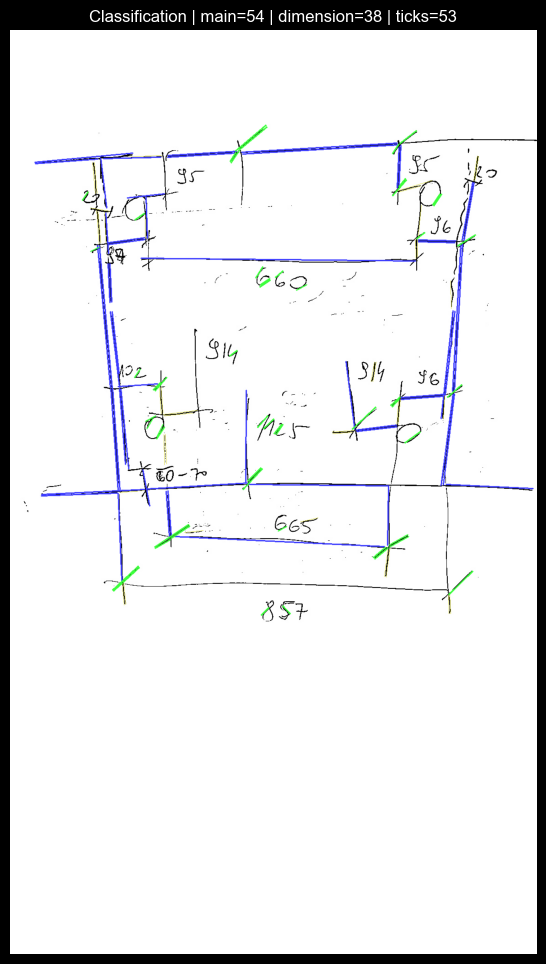

In [8]:

# --- Classification ---
ANGLE_TOL_STRAIGHT = 20
ANGLE_TOL_TICK = 18
MIN_MAIN = 80
MIN_DIM = 40
MIN_TICK = 20
MAX_TICK = 90


def classify_segment(x1, y1, x2, y2, length, angle):
    is_h = angle < ANGLE_TOL_STRAIGHT or angle > (180 - ANGLE_TOL_STRAIGHT)
    is_v = abs(angle - 90) < ANGLE_TOL_STRAIGHT
    is_tick = (abs(angle - 45) < ANGLE_TOL_TICK or abs(angle - 135) < ANGLE_TOL_TICK)
    if (is_h or is_v) and length >= MIN_MAIN:
        return "main"
    elif (is_h or is_v) and length >= MIN_DIM:
        return "dimension_line"
    elif is_tick and MIN_TICK <= length <= MAX_TICK:
        return "tick"
    elif length >= MIN_DIM:
        return "other"
    return "noise"


lines_main = []
lines_dim = []
lines_tick = []
lines_other = []

for seg in all_segments:
    x1, y1, x2, y2, length, angle = seg
    typ = classify_segment(x1, y1, x2, y2, length, angle)
    entry = {"x1": x1, "y1": y1, "x2": x2, "y2": y2, "length_px": round(length, 1), "angle_deg": round(angle, 1)}
    if typ == "main":
        lines_main.append(entry)
    elif typ == "dimension_line":
        lines_dim.append(entry)
    elif typ == "tick":
        lines_tick.append(entry)
    elif typ == "other" and length > 150:
        lines_main.append(entry)

print(f"main={len(lines_main)}, dimension={len(lines_dim)}, ticks={len(lines_tick)}")

vis_class = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for l in lines_main: cv2.line(vis_class, (l['x1'], l['y1']), (l['x2'], l['y2']), (255, 60, 60), 2)
for l in lines_dim: cv2.line(vis_class, (l['x1'], l['y1']), (l['x2'], l['y2']), (60, 220, 220), 1)
for l in lines_tick: cv2.line(vis_class, (l['x1'], l['y1']), (l['x2'], l['y2']), (60, 255, 60), 2)
plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis_class, cv2.COLOR_BGR2RGB))
plt.title(f"Classification | main={len(lines_main)} | dimension={len(lines_dim)} | ticks={len(lines_tick)}")
plt.axis('off');
plt.show()


Filtered: H=22, V=30
Rectangle: (204,257)→(1003,1016)  799x759px


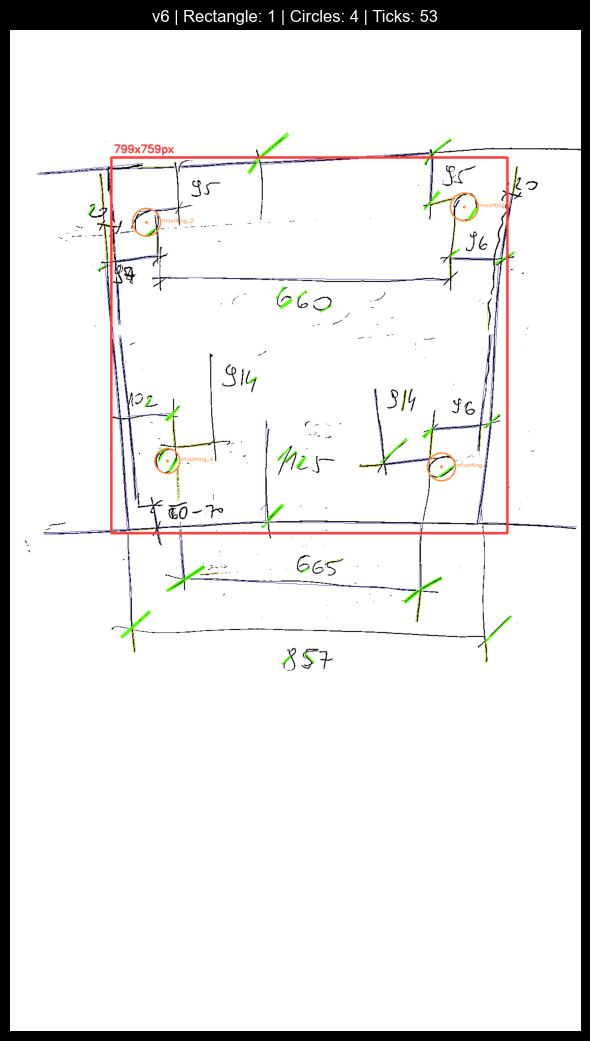

In [9]:

# --- Rectangle extraction (filtered) ---
def mid_y(l): return (l['y1'] + l['y2']) / 2


def mid_x(l): return (l['x1'] + l['x2']) / 2


main_h = [l for l in lines_main if l['angle_deg'] < ANGLE_TOL_STRAIGHT or l['angle_deg'] > (180 - ANGLE_TOL_STRAIGHT)]
main_v = [l for l in lines_main if abs(l['angle_deg'] - 90) < ANGLE_TOL_STRAIGHT]

MAX_H_LENGTH = 400
MIN_H_LENGTH = 80
main_h_filtered = [l for l in main_h if MIN_H_LENGTH <= l['length_px'] <= MAX_H_LENGTH]
main_v_filtered = [l for l in main_v if l['length_px'] >= MIN_H_LENGTH]

print(f"Filtered: H={len(main_h_filtered)}, V={len(main_v_filtered)}")
rectangles = []
if len(main_h_filtered) >= 2 and len(main_v_filtered) >= 2:
    top_line = min(main_h_filtered, key=mid_y)
    bottom_line = max(main_h_filtered, key=mid_y)
    left_line = min(main_v_filtered, key=mid_x)
    right_line = max(main_v_filtered, key=mid_x)
    x1r = int(mid_x(left_line));
    x2r = int(mid_x(right_line))
    y1r = int(mid_y(top_line));
    y2r = int(mid_y(bottom_line))
    rectangles.append({"label": "outer", "x1": x1r, "y1": y1r, "x2": x2r, "y2": y2r,
                       "width_px": x2r - x1r, "height_px": y2r - y1r})
    print(f"Rectangle: ({x1r},{y1r})→({x2r},{y2r})  {x2r - x1r}x{y2r - y1r}px")

# --- Circles from contours ---
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
skeleton_closed = cv2.morphologyEx(skeleton, cv2.MORPH_CLOSE, kernel_close)
circle_contours, _ = cv2.findContours(skeleton_closed, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

circles_all = []
for cnt in circle_contours:
    area = cv2.contourArea(cnt)
    if area < 300 or area > 12000: continue
    peri = cv2.arcLength(cnt, True)
    if peri < 1: continue
    circularity = 4 * np.pi * area / (peri * peri)
    if circularity > 0.60:
        (cx, cy), rad = cv2.minEnclosingCircle(cnt)
        circles_all.append({"cx": int(cx), "cy": int(cy), "radius_px": int(rad), "circularity": round(circularity, 3)})

circles_clean = []
for c in sorted(circles_all, key=lambda x: -x['radius_px']):
    if not any(np.hypot(c['cx'] - e['cx'], c['cy'] - e['cy']) < 25 for e in circles_clean):
        circles_clean.append(c)
circles_mounting = sorted(circles_clean, key=lambda x: -x['radius_px'])[:4]
for i, c in enumerate(circles_mounting):
    c['label'] = f"mounting_{i + 1}"

# --- Final visualization ---
vis_final = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for l in lines_dim: cv2.line(vis_final, (l['x1'], l['y1']), (l['x2'], l['y2']), (0, 200, 200), 1)
for l in lines_tick: cv2.line(vis_final, (l['x1'], l['y1']), (l['x2'], l['y2']), (0, 255, 80), 2)
for l in lines_main: cv2.line(vis_final, (l['x1'], l['y1']), (l['x2'], l['y2']), (180, 60, 60), 1)
if rectangles:
    r = rectangles[0]
    cv2.rectangle(vis_final, (r['x1'], r['y1']), (r['x2'], r['y2']), (60, 60, 255), 3)
    cv2.putText(vis_final, f"{r['width_px']}x{r['height_px']}px", (r['x1'] + 5, r['y1'] - 10), cv2.FONT_HERSHEY_SIMPLEX,
                0.7, (60, 60, 255), 2)
for c in circles_mounting:
    cv2.circle(vis_final, (c['cx'], c['cy']), c['radius_px'], (60, 140, 255), 2)
    cv2.circle(vis_final, (c['cx'], c['cy']), 3, (60, 140, 255), -1)
    cv2.putText(vis_final, c['label'], (c['cx'] + c['radius_px'] + 3, c['cy']), cv2.FONT_HERSHEY_SIMPLEX, 0.35,
                (60, 140, 255), 1)

plt.figure(figsize=(9, 13))
plt.imshow(cv2.cvtColor(vis_final, cv2.COLOR_BGR2RGB))
plt.title(f"v6 | Rectangle: {len(rectangles)} | Circles: {len(circles_mounting)} | Ticks: {len(lines_tick)}")
plt.axis('off');
plt.show()


✓ JSON saved: C:\python\Intelligent_Sketch2CAD\output_data\deeplsd_v6_20260511_192510.json
✓ DXF saved: C:\python\Intelligent_Sketch2CAD\output_data\sketch_20260511_192510.dxf
Scale: 1.073 mm/px (X)  0.870 mm/px (Y)


C:\Users\tomas\AppData\Local\Temp\ipykernel_8848\1000744121.py:191: UserWarning: Glyph 8960 (\N{DIAMETER SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\tomas\AppData\Local\Temp\ipykernel_8848\1000744121.py:196: UserWarning: Glyph 8960 (\N{DIAMETER SIGN}) missing from current font.
  plt.savefig(str(output_png), dpi=200, bbox_inches='tight', facecolor='white')
C:\Users\tomas\AppData\Local\Temp\ipykernel_8848\1000744121.py:197: UserWarning: Glyph 8960 (\N{DIAMETER SIGN}) missing from current font.
  plt.savefig(str(output_pdf), bbox_inches='tight', facecolor='white')
C:\Users\tomas\AppData\Local\Temp\ipykernel_8848\1000744121.py:197: UserWarning: Glyph 8960 (\N{DIAMETER SIGN}) missing from current font.
  plt.savefig(str(output_pdf), bbox_inches='tight', facecolor='white')
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8960 (\N{DIAMETER SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


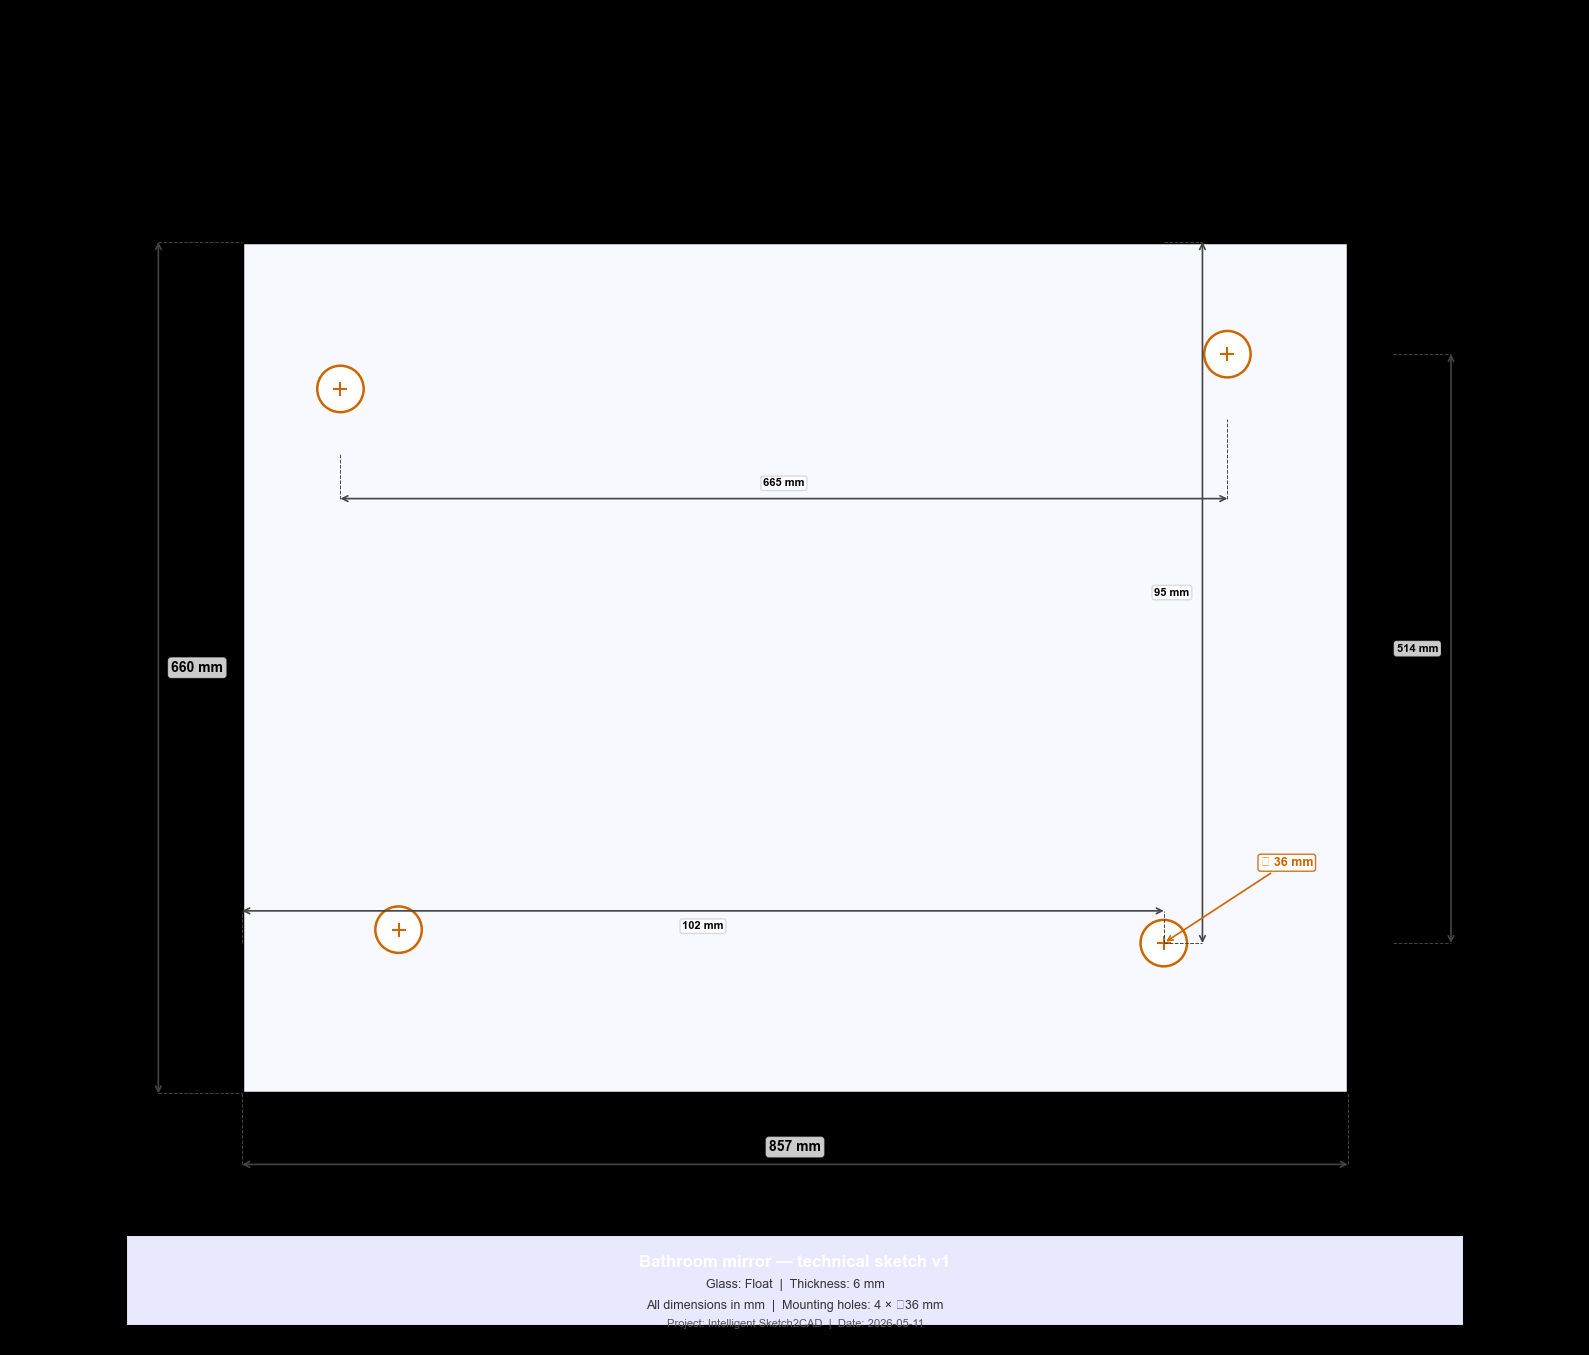


✅ Technical drawing saved:
   PNG: C:\python\Intelligent_Sketch2CAD\output_data\technical_drawing_20260511_192510.png
   PDF: C:\python\Intelligent_Sketch2CAD\output_data\technical_drawing_20260511_192510.pdf

VERTICAL SLICE COMPLETE
  📐 Rectangle: 857 × 660 mm
  ⭕ Circles: 4 × ⌀36 mm
  📄 JSON: deeplsd_v6_20260511_192510.json
  📁 DXF: sketch_20260511_192510.dxf
  🖼️  Technical drawing: technical_drawing_20260511_192510.pdf

✅ Ready for glass order submission


In [13]:
# --- Save JSON ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
data = {
    "timestamp": timestamp,
    "source_image": str(latest_file),
    "image_size": {"height": h, "width": w},
    "method": "DeepLSD v6 - filtered H/V + contour circles",
    "rectangles": rectangles,
    "circles": circles_mounting,
    "lines": {"main": lines_main, "dimension_lines": lines_dim, "ticks": lines_tick},
    "statistics": {
        "deeplsd_raw": len(all_segments),
        "main": len(lines_main),
        "dimension": len(lines_dim),
        "ticks": len(lines_tick),
        "circles_mounting": len(circles_mounting)
    },
    "notes": {"scale_hint": "857mm = external width"}
}
json_path = OUTPUT_DIR / f"deeplsd_v6_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)
print(f"\n✓ JSON saved: {json_path}")

# --- Export DXF ---
import ezdxf

doc = ezdxf.new('R2010')
msp = doc.modelspace()
if rectangles:
    r = rectangles[0]
    msp.add_lwpolyline(
        [(r['x1'], -r['y1']), (r['x2'], -r['y1']), (r['x2'], -r['y2']), (r['x1'], -r['y2']), (r['x1'], -r['y1'])])
for c in circles_mounting:
    msp.add_circle(center=(c['cx'], -c['cy']), radius=c['radius_px'])
dxf_path = OUTPUT_DIR / f"sketch_{timestamp}.dxf"
doc.saveas(str(dxf_path))
print(f"✓ DXF saved: {dxf_path}")

# --- Technical drawing with manual dimensions (mm) ---
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

# Manual dimensions (from the original sketch)
dims = {
    "width_mm":  857,
    "height_mm": 660,
    "offset_top_mm":    95,
    "offset_bottom_mm": 95,
    "offset_left_mm":  102,
    "offset_right_mm":  96,
    "hole_spacing_h_mm": 665,
    "hole_spacing_v_mm": 514,
    "hole_diameter_mm":  36,
    "glass_type": "Float",
    "glass_thickness_mm": 6,
    "note": "Bathroom mirror — technical sketch v1"
}

# Calibration px→mm
if rectangles:
    r = rectangles[0]
    width_px = r['width_px']
    height_px = r['height_px']
    scale_x = dims['width_mm'] / width_px
    scale_y = dims['height_mm'] / height_px
    print(f"Scale: {scale_x:.3f} mm/px (X)  {scale_y:.3f} mm/px (Y)")

    def to_mm(px_x, px_y):
        return ((px_x - r['x1']) * scale_x, (px_y - r['y1']) * scale_y)

    circles_mm = []
    for c in circles_mounting:
        cx_mm, cy_mm = to_mm(c['cx'], c['cy'])
        circles_mm.append({'cx': cx_mm, 'cy': cy_mm, 'r': dims['hole_diameter_mm'] / 2, 'label': c['label']})
else:
    circles_mm = []
    print("⚠ No rectangle found – using default circles list")

# Plot technical drawing
MARGIN = 180  # increased for better readability
fig, ax = plt.subplots(figsize=(16, 14))  # larger figure
ax.set_aspect('equal')
ax.set_facecolor('white')
ax.axis('off')

# Main rectangle
ax.add_patch(patches.Rectangle((0, 0), dims['width_mm'], dims['height_mm'],
                               linewidth=2.5, edgecolor='black', facecolor='#f8f8ff'))

# Circles with crosshairs
for c in circles_mm:
    ax.add_patch(patches.Circle((c['cx'], dims['height_mm'] - c['cy']), c['r'],
                                linewidth=1.8, edgecolor='#cc6600', facecolor='white'))
    ax.plot(c['cx'], dims['height_mm'] - c['cy'], '+', color='#cc6600', markersize=10, markeredgewidth=1.5)

# Dimension line helper (improved)
def dim_line(ax, x1, y1, x2, y2, text, offset=0, orient='h', fontsize=9, offset_text=None):
    color = '#444444'
    if orient == 'h':
        y = y1 + offset
        # Extension lines
        ax.plot([x1, x1], [min(y1, y), max(y1, y)], color=color, lw=0.7, ls='--')
        ax.plot([x2, x2], [min(y2, y), max(y2, y)], color=color, lw=0.7, ls='--')
        # Dimension line with arrows
        ax.annotate('', xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle='<->', color=color, lw=1.2, shrinkA=0, shrinkB=0))
        # Text position
        text_y = y - 8 if offset > 0 else y + 8
        va = 'top' if offset > 0 else 'bottom'
        ax.text((x1 + x2) / 2, text_y, text, ha='center', va=va,
                fontsize=fontsize, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='lightgray', alpha=0.8))
    else:  # vertical
        x = x1 + offset
        # Extension lines
        ax.plot([min(x1, x), max(x1, x)], [y1, y1], color=color, lw=0.7, ls='--')
        ax.plot([min(x2, x), max(x2, x)], [y2, y2], color=color, lw=0.7, ls='--')
        # Dimension line
        ax.annotate('', xy=(x, y2), xytext=(x, y1),
                    arrowprops=dict(arrowstyle='<->', color=color, lw=1.2, shrinkA=0, shrinkB=0))
        # Text position
        text_x = x - 10 if offset > 0 else x + 10
        ha = 'right' if offset > 0 else 'left'
        ax.text(text_x, (y1 + y2) / 2, text, ha=ha, va='center',
                fontsize=fontsize, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='lightgray', alpha=0.8))

# --- Main dimensions ---
dim_line(ax, 0, 0, dims['width_mm'], 0, f'{dims["width_mm"]} mm',
         offset=-55, orient='h', fontsize=10)
dim_line(ax, 0, 0, 0, dims['height_mm'], f'{dims["height_mm"]} mm',
         offset=-65, orient='v', fontsize=10)

# --- Hole dimensions (from edges) ---
if len(circles_mm) >= 1:
    c = circles_mm[0]  # first hole (usually top-left)
    # Horizontal offset from left edge
    dim_line(ax, 0, dims['height_mm'] - c['cy'], c['cx'], dims['height_mm'] - c['cy'],
             f'{dims["offset_left_mm"]} mm', offset=25, orient='h', fontsize=8)
    # Vertical offset from top edge
    dim_line(ax, c['cx'], dims['height_mm'], c['cx'], dims['height_mm'] - c['cy'],
             f'{dims["offset_top_mm"]} mm', offset=30, orient='v', fontsize=8)

# --- Hole spacing ---
if len(circles_mm) >= 2:
    c_left = min(circles_mm, key=lambda c: c['cx'])
    c_right = max(circles_mm, key=lambda c: c['cx'])
    dim_line(ax, c_left['cx'], dims['height_mm'] - c_left['cy'] - 50,
             c_right['cx'], dims['height_mm'] - c_right['cy'] - 50,
             f'{dims["hole_spacing_h_mm"]} mm', offset=-35, orient='h', fontsize=8)

    c_top = min(circles_mm, key=lambda c: c['cy'])
    c_bottom = max(circles_mm, key=lambda c: c['cy'])
    dim_line(ax, dims['width_mm'] + 35, dims['height_mm'] - c_bottom['cy'],
             dims['width_mm'] + 35, dims['height_mm'] - c_top['cy'],
             f'{dims["hole_spacing_v_mm"]} mm', offset=45, orient='v', fontsize=8)

# --- Hole diameter annotation ---
if circles_mm:
    c = circles_mm[0]
    ax.annotate(f'⌀ {dims["hole_diameter_mm"]} mm',
                xy=(c['cx'], dims['height_mm'] - c['cy']),
                xytext=(c['cx'] + 75, dims['height_mm'] - c['cy'] + 60),
                fontsize=9, fontweight='bold', color='#cc6600',
                arrowprops=dict(arrowstyle='->', color='#cc6600', lw=1.2),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#cc6600', alpha=0.9))

# --- Title block ---
title_y = -110
title_block_height = 70
ax.add_patch(patches.Rectangle((-MARGIN/2, title_y - title_block_height),
                                dims['width_mm'] + MARGIN, title_block_height,
                                linewidth=1.5, edgecolor='black', facecolor='#e8e8ff'))

ax.text(dims['width_mm'] / 2, title_y - 15, dims['note'],
        ha='center', va='top', fontsize=12, fontweight='bold')
ax.text(dims['width_mm'] / 2, title_y - 33,
        f'Glass: {dims["glass_type"]}  |  Thickness: {dims["glass_thickness_mm"]} mm',
        ha='center', va='top', fontsize=9, color='#333333')
ax.text(dims['width_mm'] / 2, title_y - 50,
        f'All dimensions in mm  |  Mounting holes: 4 × ⌀{dims["hole_diameter_mm"]} mm',
        ha='center', va='top', fontsize=9, color='#333333')
ax.text(dims['width_mm'] / 2, title_y - 65,
        f'Project: Intelligent Sketch2CAD  |  Date: {datetime.now().strftime("%Y-%m-%d")}',
        ha='center', va='top', fontsize=8, color='#555555')

# Set limits
ax.set_xlim(-MARGIN, dims['width_mm'] + MARGIN)
ax.set_ylim(title_y - title_block_height - 15, dims['height_mm'] + MARGIN)
plt.tight_layout()

# Save to OUTPUT_DIR (not INTERMEDIATE_DIR)
output_png = OUTPUT_DIR / f"technical_drawing_{timestamp}.png"
output_pdf = OUTPUT_DIR / f"technical_drawing_{timestamp}.pdf"
plt.savefig(str(output_png), dpi=200, bbox_inches='tight', facecolor='white')
plt.savefig(str(output_pdf), bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Technical drawing saved:")
print(f"   PNG: {output_png}")
print(f"   PDF: {output_pdf}")
print("\n" + "="*60)
print("VERTICAL SLICE COMPLETE")
print("="*60)
print(f"  📐 Rectangle: {dims['width_mm']} × {dims['height_mm']} mm")
print(f"  ⭕ Circles: {len(circles_mm)} × ⌀{dims['hole_diameter_mm']} mm")
print(f"  📄 JSON: {json_path.name}")
print(f"  📁 DXF: {dxf_path.name}")
print(f"  🖼️  Technical drawing: technical_drawing_{timestamp}.pdf")
print("\n✅ Ready for glass order submission")